# Credit Scoring Model — Predicting Creditworthiness

**Task 1 — Machine Learning Internship**

**Problem.** Given an individual's past financial behaviour, predict whether they
are creditworthy. Formally: a **binary classification** problem where
`default = 1` means the customer failed to pay their next credit-card bill.

**Dataset.** UCI *Default of Credit Card Clients* (Taiwan, 2005) — 30,000 real
credit-card customers with six months of billing, payment and delinquency
history.

**Why classification?** The outcome is a discrete yes/no label, and lenders need
a *probability* of default to set a lending cut-off — exactly what a probabilistic
classifier provides.

> This notebook reproduces the analysis. The heavy hyper-parameter search lives in
> `src/train.py`; run `python -m src.train` first, then this notebook loads those
> results.

In [1]:
import sys, json, warnings
from pathlib import Path

# Make the project importable when the notebook runs from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import config
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
print("Project root:", ROOT)
print("Random seed :", config.RANDOM_STATE)

Project root: C:\practice
Random seed : 42


## 1. Data acquisition and cleaning

`src/data_loader.py` downloads the official UCI archive (cached locally), then applies
four cleaning decisions:

1. **Drop `ID`** — a row identifier carries no signal and would act as a leakage-style shortcut.
2. **Rename** the verbose target to `default`.
3. **Drop 35 exact duplicates** so the same customer cannot appear in both train and test.
4. **Recode `SEX` / `EDUCATION` / `MARRIAGE`** to readable labels, folding *undocumented*
   codes (EDUCATION 0/5/6, MARRIAGE 0) into `others`.

In [2]:
from src.data_loader import load_clean

df = load_clean()
print("Shape:", df.shape)
df.head()

Shape: (29965, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,female,university,married,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,female,university,single,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,female,university,single,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,female,university,married,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,male,university,married,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Data understanding

Shape, types, missingness, duplicates, and the target distribution.

In [3]:
print("Rows, columns :", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print()
print("Data types:")
print(df.dtypes.value_counts().to_string())
print()
counts = df[config.TARGET].value_counts().sort_index()
print("Target distribution:")
print(counts.to_string())
print(f"Default rate    : {df[config.TARGET].mean():.2%}")
print(f"Imbalance ratio : {counts[0] / counts[1]:.2f} : 1")

Rows, columns : (29965, 24)
Missing values: 0
Duplicate rows: 0

Data types:
int64    21
str       3

Target distribution:
default
0    23335
1     6630
Default rate    : 22.13%
Imbalance ratio : 3.52 : 1


In [4]:
# Numerical summary of the key financial columns
df[["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1", "PAY_0"]].describe().round(1)

,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1,PAY_0
count,29965.0,29965.0,29965.0,29965.0,29965.0
mean,167442.0,35.5,51283.0,5670.1,-0.0
std,129760.1,9.2,73658.1,16571.8,1.1
min,10000.0,21.0,-165580.0,0.0,-2.0
25%,50000.0,28.0,3595.0,1000.0,-1.0
50%,140000.0,34.0,22438.0,2102.0,0.0
75%,240000.0,41.0,67260.0,5008.0,0.0
max,1000000.0,79.0,964511.0,873552.0,8.0


In [5]:
# Categorical summary
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().to_string())
    print()

--- SEX ---
SEX
female    18091
male      11874

--- EDUCATION ---
EDUCATION
university         14019
graduate_school    10563
high_school         4915
others               468

--- MARRIAGE ---
MARRIAGE
single     15945
married    13643
others       377



### Columns that must NOT be used

| Column | Why it is excluded |
|---|---|
| `ID` | Pure row identifier. No causal link to default; a tree could memorise it. Dropped in cleaning. |
| `default` | The target itself — excluded from `X` by construction. |

**Leakage audit.** The target is default in **October 2005**; every predictor
describes **April–September 2005**. All features therefore precede the outcome
in time, so there is no look-ahead leakage. `PAY_0` (September status) is the
most recent signal but is legitimately known before the October bill.

## 3. Exploratory Data Analysis

Five figures, each answering a question that changes a modelling decision.
They are generated by `src/eda.py`.

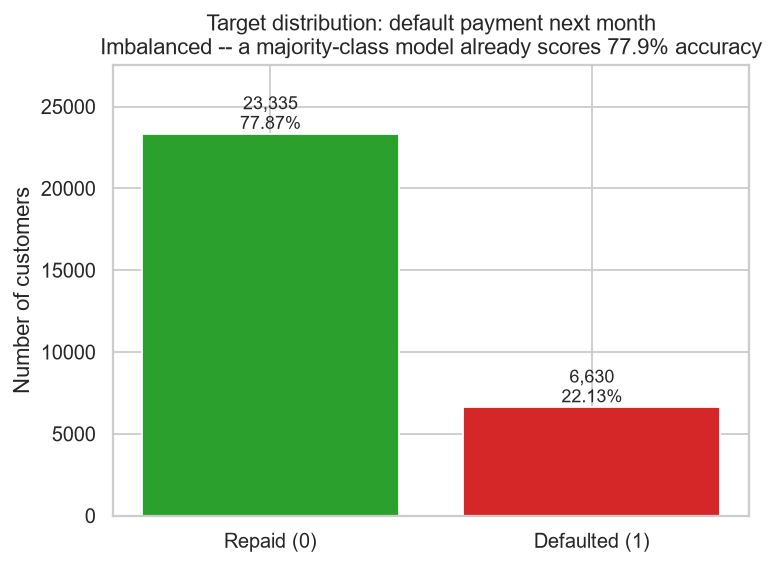

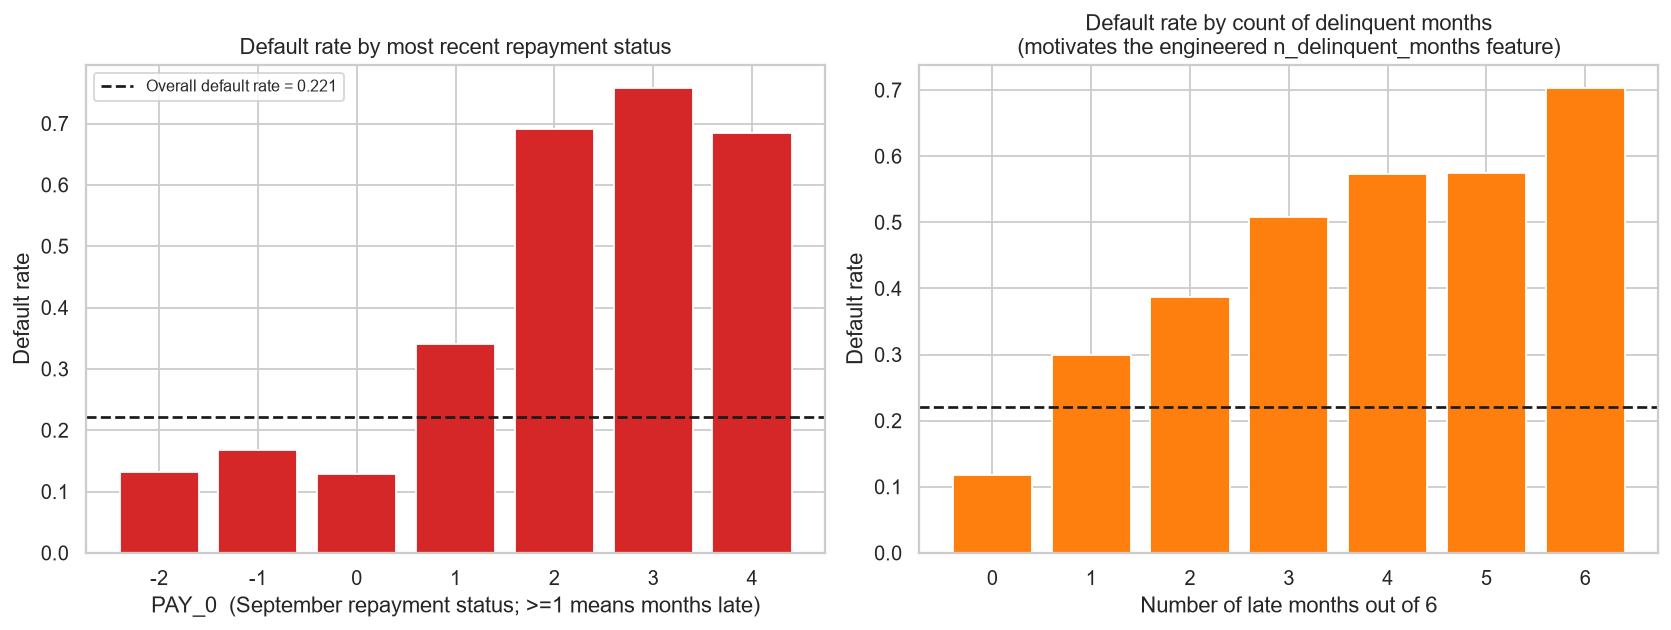

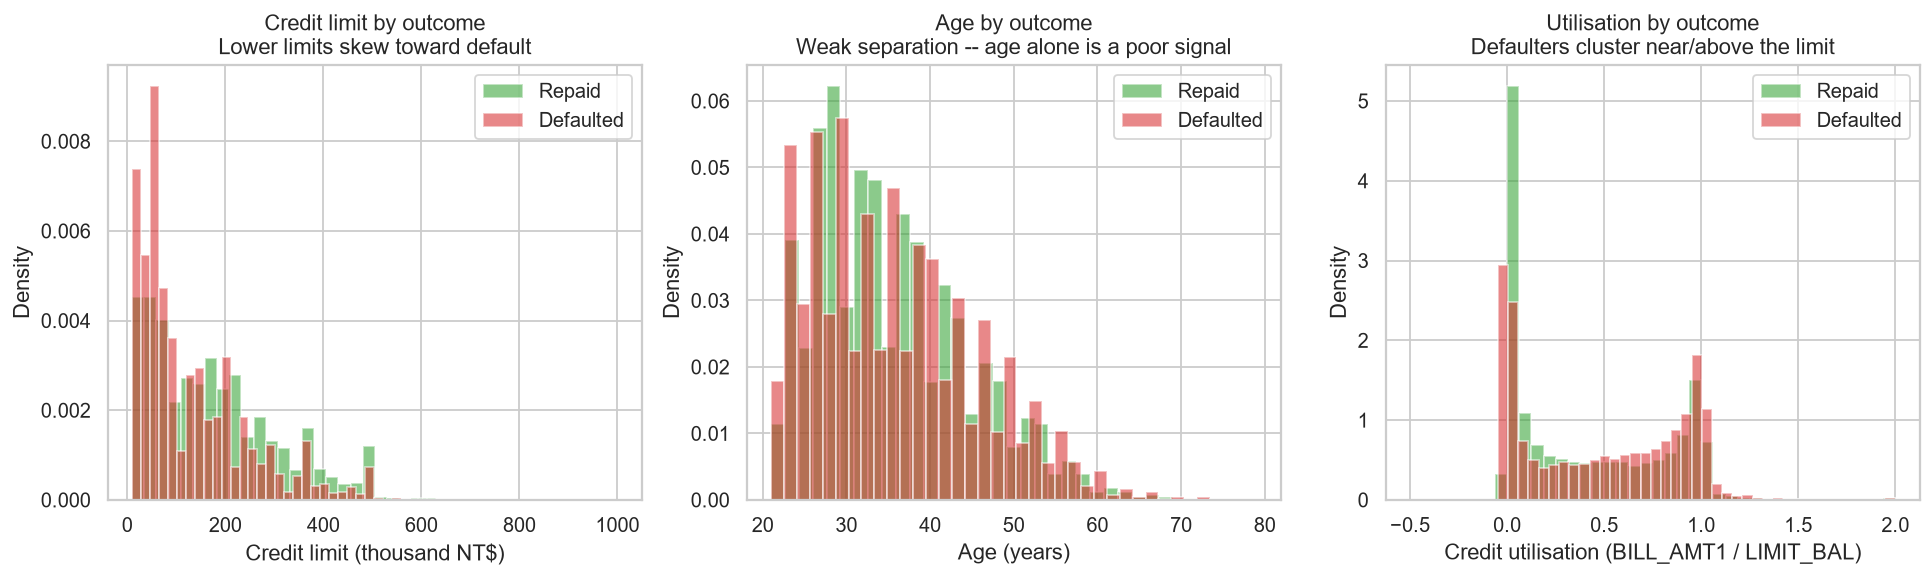

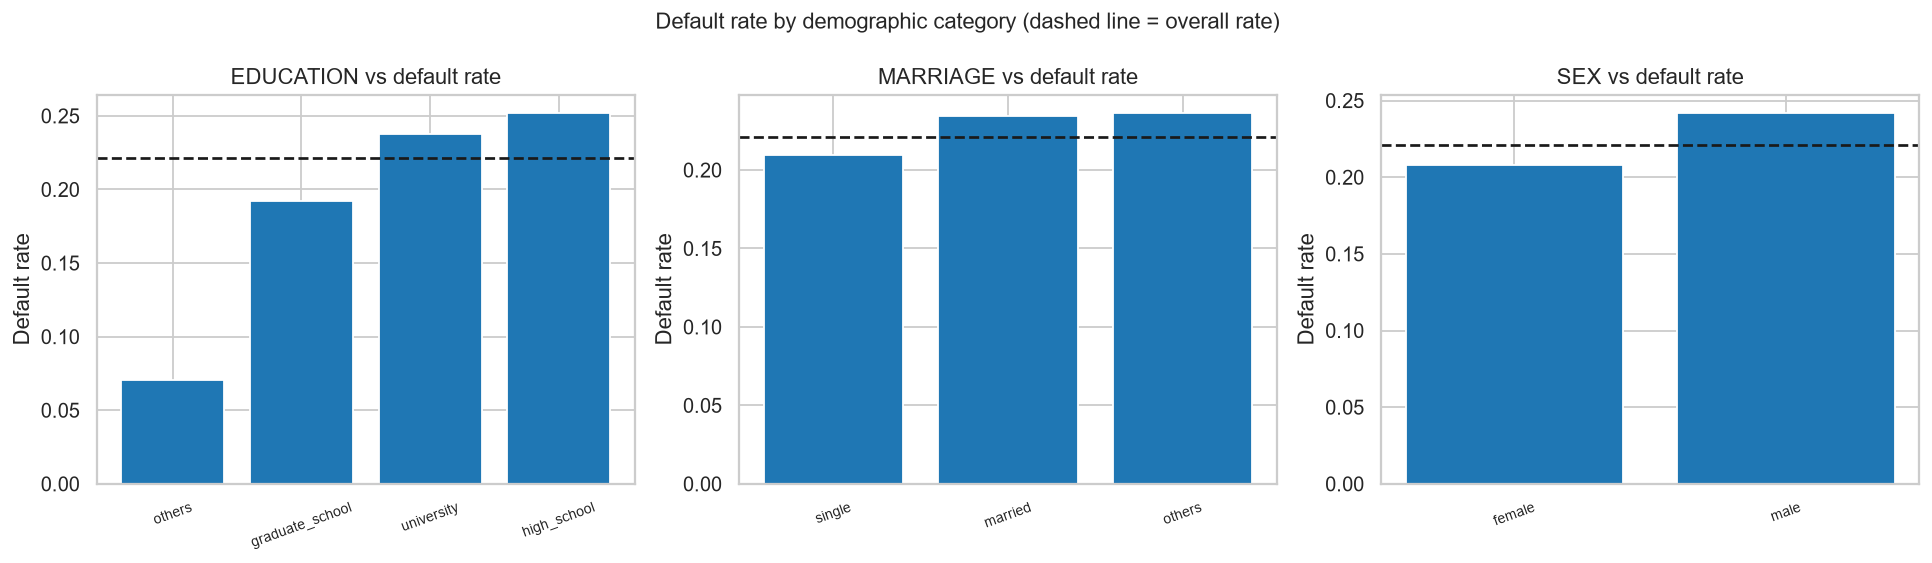

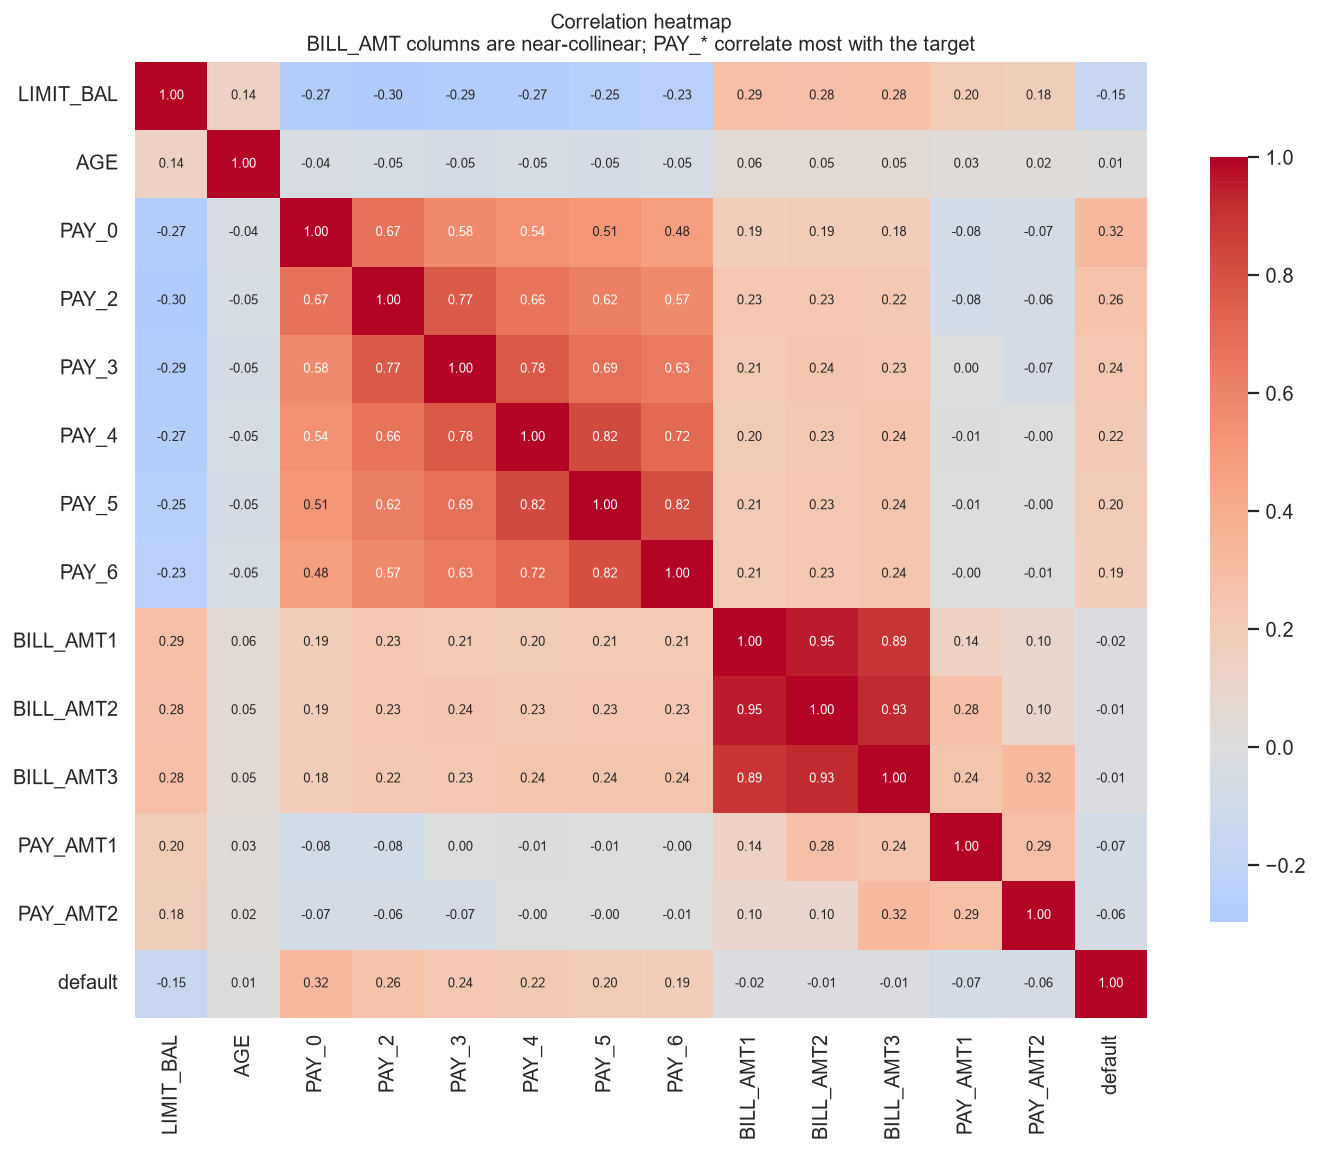

In [6]:
from src import eda

paths = eda.run_all(df)
for p in paths:
    display(Image(filename=p))

**What the EDA tells us**

1. **Target distribution** — 22.1% default. A model predicting "nobody defaults"
   already scores ~78% accuracy, so **accuracy alone is a misleading metric**.
2. **Payment history** — the default rate climbs steeply with `PAY_0` and with the
   number of late months. This is the dominant signal and motivates the engineered
   delinquency features.
3. **Financial profile** — defaulters cluster at *lower credit limits* and *higher
   utilisation*; age separates the classes poorly.
4. **Categoricals** — education and marital status shift the default rate modestly,
   so they are worth one-hot encoding.
5. **Correlation** — the six `BILL_AMT` columns are almost collinear (r > 0.9), which
   is why ratio features (utilisation) carry more information than raw balances.

## 4. Feature engineering

Every feature is computed **row-wise from a single customer's own record**, so this
step is leakage-free and may run before the split. Statistics that *are* learned from
data (imputation medians, scaler means, one-hot categories) live inside the sklearn
Pipeline instead.

| Group | Features | Financial meaning |
|---|---|---|
| Utilisation | `util_1..6`, `avg_utilization`, `max_utilization`, `utilization_trend`, `over_limit_months` | Share of the granted limit consumed. Sustained high utilisation signals stress. |
| Repayment effort | `pay_ratio_1..5`, `avg_pay_ratio`, `min_pay_ratio`, `zero_payment_months` | How much of last month's bill was actually paid off. |
| Delinquency | `n_delinquent_months`, `max_delinquency`, `recent_delinquency`, `delinquency_trend`, `months_paid_full`, `months_no_consumption` | Frequency, severity and *direction* of late payments. |
| Burden | `avg_bill_amt`, `avg_pay_amt`, `bill_volatility`, `payment_to_limit`, `remaining_credit` | Absolute debt load and capacity to service it. |

**Timing detail that matters:** `PAY_AMT_t` is the money paid *during* month *t*, which
settles the bill raised in month *t+1*. So `pay_ratio_t = PAY_AMT_t / BILL_AMT_{t+1}`.

In [7]:
from src.feature_engineering import (
    add_financial_features, engineered_feature_names, get_feature_lists,
)

feat = add_financial_features(df)
numeric, categorical = get_feature_lists()

print(f"Before : {df.shape[1] - 1} predictors")
print(f"After  : {len(numeric)} numeric + {len(categorical)} categorical "
      f"= {len(numeric) + len(categorical)} predictors")
print(f"Created: {len(engineered_feature_names())} new features")

feat[["LIMIT_BAL", "avg_utilization", "n_delinquent_months",
      "avg_pay_ratio", "delinquency_trend", config.TARGET]].head()

Before : 23 predictors
After  : 49 numeric + 3 categorical = 52 predictors
Created: 29 new features


,LIMIT_BAL,avg_utilization,n_delinquent_months,avg_pay_ratio,delinquency_trend,default
0,20000,0.064200,2,0.500000,4,1
1,120000,0.023718,2,0.193583,-3,1
2,90000,0.188246,0,0.083968,0,0
3,50000,0.771113,0,0.039794,0,0
4,50000,0.364463,0,0.471997,-1,0


In [8]:
# NaNs appear only where a ratio is genuinely undefined (no bill to repay).
# They are imputed INSIDE the pipeline, per fold - never globally.
nan_counts = feat[numeric].isna().sum()
nan_counts[nan_counts > 0].to_frame("missing")

,missing
pay_ratio_1,3145
pay_ratio_2,3495
pay_ratio_3,3840
pay_ratio_4,4131
pay_ratio_5,4678
avg_pay_ratio,1376
min_pay_ratio,1376


In [9]:
# Do the engineered features actually separate the classes?
key = ["avg_utilization", "n_delinquent_months", "avg_pay_ratio",
       "max_delinquency", "payment_to_limit"]
feat.groupby(config.TARGET)[key].mean().round(3).T.rename(
    columns={0: "repaid", 1: "defaulted"})

default,repaid,defaulted
avg_utilization,0.352,0.450
n_delinquent_months,0.504,1.996
avg_pay_ratio,0.414,0.282
max_delinquency,0.202,1.275
payment_to_limit,0.040,0.035


## 5. Train / validation / test strategy

* **Train (80%)** — model fitting *and* all hyper-parameter search.
* **Validation** — 5-fold **stratified** cross-validation *inside* the training set.
  Stratification keeps the 22% default rate in every fold.
* **Test (20%)** — touched exactly once, for the final report. Never used for tuning
  or for choosing the decision threshold.

This is why the reported test scores are an honest estimate of new-customer performance.

In [10]:
from sklearn.model_selection import train_test_split

X = feat[numeric + categorical]
y = feat[config.TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, stratify=y, random_state=config.RANDOM_STATE,
)
print(f"Train: {len(X_train):,} rows | default rate {y_train.mean():.4f}")
print(f"Test : {len(X_test):,} rows | default rate {y_test.mean():.4f}")
print("Index overlap:", len(set(X_train.index) & set(X_test.index)))

Train: 23,972 rows | default rate 0.2213
Test : 5,993 rows | default rate 0.2213
Index overlap: 0


## 6. Preprocessing pipeline

`ColumnTransformer` inside a `Pipeline`, so every statistic is learned per fold:

* **Numeric** → median imputation → standard scaling *(scaling only for Logistic
  Regression; tree ensembles are invariant to monotone rescaling)*
* **Categorical** → most-frequent imputation → one-hot encoding with
  `handle_unknown="ignore"` so an unseen category cannot crash scoring.

In [11]:
from src.preprocessing import build_preprocessor

pre = build_preprocessor(numeric, categorical, scale=True)
Xt = pre.fit_transform(X_train)
print("Transformed training matrix:", Xt.shape)
print("Any NaN left? ", bool(np.isnan(Xt).any()))
print("First 8 output columns:", list(pre.get_feature_names_out())[:8])

Transformed training matrix: (23972, 58)
Any NaN left?  False
First 8 output columns: ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


## 7. Baseline and model comparison (cross-validated)

The **baseline** always predicts the majority class. It is the number every real model
must beat — and it exposes the accuracy trap: ~78% accuracy while catching *zero*
defaulters.

Below is a fast 3-fold comparison for the notebook. `src/train.py` runs the full
5-fold version plus the hyper-parameter search.

In [12]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from src.models import build_models

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=config.RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

rows = {}
for name, pipe in build_models(numeric, categorical, balanced=True).items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows[name] = {m.capitalize(): res[f"test_{m}"].mean() for m in scoring}

quick_cv = pd.DataFrame(rows).T.rename(columns={"Roc_auc": "ROC-AUC"})
quick_cv.round(4).sort_values("ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
HistGradientBoosting,0.7586,0.4666,0.6344,0.5377,0.7856
Random Forest,0.7834,0.5094,0.5794,0.5421,0.7827
Decision Tree,0.7530,0.4574,0.6207,0.5266,0.7722
Logistic Regression,0.7549,0.4599,0.6163,0.5268,0.7669
Baseline (Majority),0.7787,0.0000,0.0000,0.0000,0.5000


## 8. Full results from `src/train.py`

Everything below is loaded from disk — produced by executed code, never typed by hand.

In [13]:
cv_table = pd.read_csv(config.RESULTS_DIR / "cv_comparison.csv", index_col=0)
print("5-fold cross-validated comparison (training set only)")
cv_table.round(4)

5-fold cross-validated comparison (training set only)


,Accuracy,Precision,Recall,F1,ROC-AUC,ROC-AUC_std,PR-AUC,fit_seconds
HistGradientBoosting,0.7611,0.4704,0.6348,0.5403,0.7869,0.0083,0.5627,22.6955
Random Forest,0.7857,0.5142,0.5756,0.5431,0.7840,0.0097,0.5543,26.9791
Decision Tree,0.7528,0.4617,0.6354,0.5326,0.7766,0.0052,0.5290,1.9824
Logistic Regression,0.7563,0.4618,0.6139,0.5271,0.7666,0.0100,0.5053,1.3365
Baseline (Majority),0.7787,0.0000,0.0000,0.0000,0.5000,0.0000,0.2213,0.6477


In [14]:
imb = pd.read_csv(config.RESULTS_DIR / "imbalance_study.csv")
print("Class-imbalance mitigation: class_weight='balanced' vs none")
imb.round(4)

Class-imbalance mitigation: class_weight='balanced' vs none


,Model,class_weight,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,none,0.6303,0.3039,0.4099,0.7643
1,Random Forest,none,0.6604,0.3729,0.4766,0.7832
2,HistGradientBoosting,none,0.6723,0.3597,0.4685,0.7861
3,Logistic Regression,balanced,0.4618,0.6139,0.5271,0.7666
4,Random Forest,balanced,0.5142,0.5756,0.5431,0.7840
5,HistGradientBoosting,balanced,0.4704,0.6348,0.5403,0.7869


**Reading the imbalance study.** Re-weighting the minority class trades precision
for a large gain in **recall** — it makes the model far more willing to flag a risky
borrower. Because a missed defaulter costs a lender much more than a wrongly declined
applicant, that trade is the right one here.

*Why not SMOTE?* SMOTE would add the `imbalanced-learn` dependency and must be applied
**inside** each CV fold (never before the split) to avoid leaking synthetic neighbours
into validation. At a 3.5:1 ratio, `class_weight` achieves the same re-balancing with
no synthetic data and no extra dependency.

In [15]:
tune = pd.read_csv(config.RESULTS_DIR / "tuning_results.csv")
print("Hyper-parameter search results")
tune

Hyper-parameter search results


,Model,Search,Combinations_tested,Best_CV_ROC_AUC,Best_params,Seconds
0,HistGradientBoosting,RandomizedSearchCV (15/216 combos),15,0.789931,"{""model__min_samples_leaf"": 50, ""model__max_le...",368.2
1,Random Forest,RandomizedSearchCV (12/144 combos),12,0.788873,"{""model__n_estimators"": 400, ""model__min_sampl...",671.3
2,Decision Tree,GridSearchCV (48 combos),48,0.776727,"{""model__criterion"": ""gini"", ""model__max_depth...",109.0
3,Logistic Regression,GridSearchCV (12 combos),12,0.766626,"{""model__C"": 1.0, ""model__solver"": ""lbfgs""}",18.9


In [16]:
test_table = pd.read_csv(config.RESULTS_DIR / "test_comparison.csv", index_col=0)
print("FINAL COMPARISON — held-out test set")
test_table.round(4)

FINAL COMPARISON — held-out test set


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline (Majority),0.7787,0.0000,0.0000,0.0000,NaN,NaN
Logistic Regression,0.7542,0.4573,0.5943,0.5169,0.7613,0.5150
Decision Tree,0.7587,0.4653,0.6063,0.5265,0.7697,0.5348
Random Forest,0.7651,0.4759,0.6094,0.5344,0.7782,0.5592
HistGradientBoosting,0.7545,0.4600,0.6282,0.5311,0.7818,0.5631
HistGradientBoosting @ thr=0.40,0.6738,0.3796,0.7481,0.5037,0.7818,0.5631


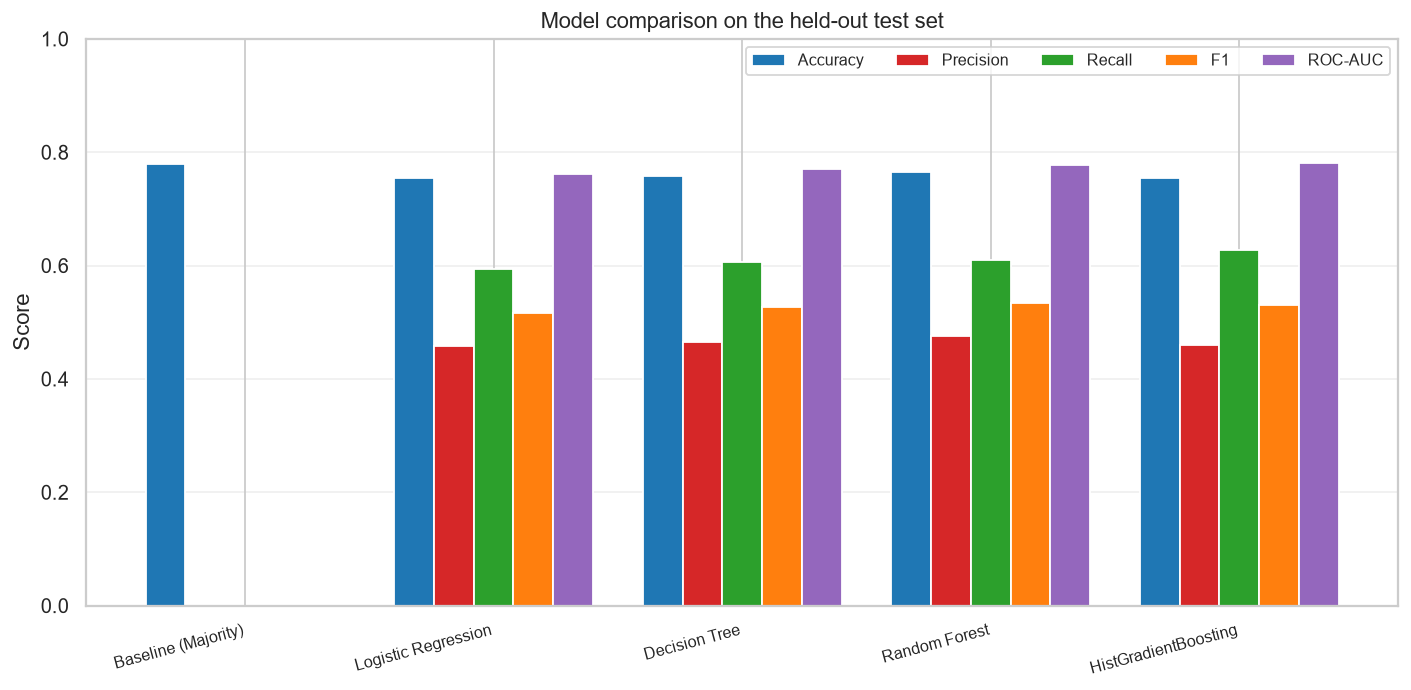

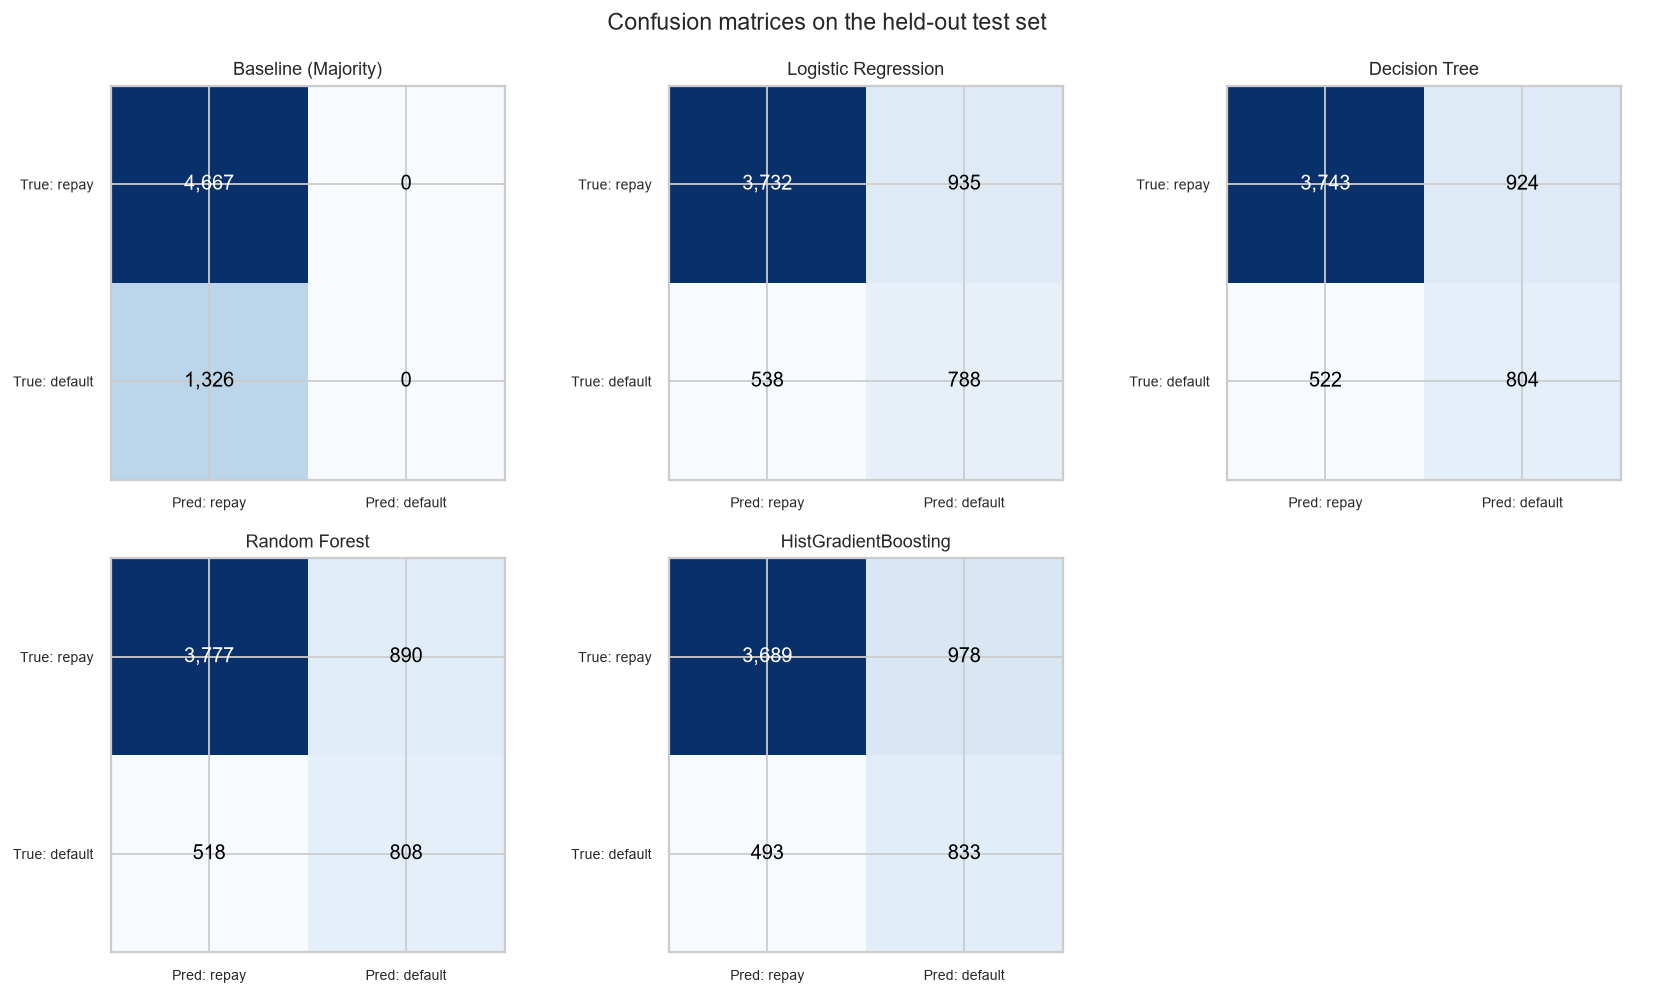

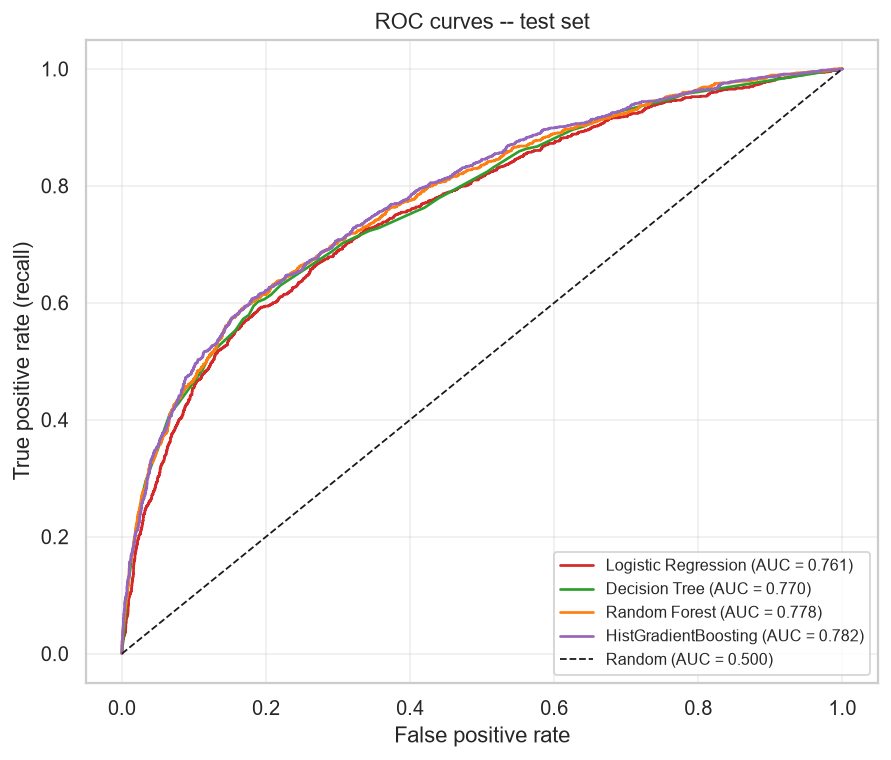

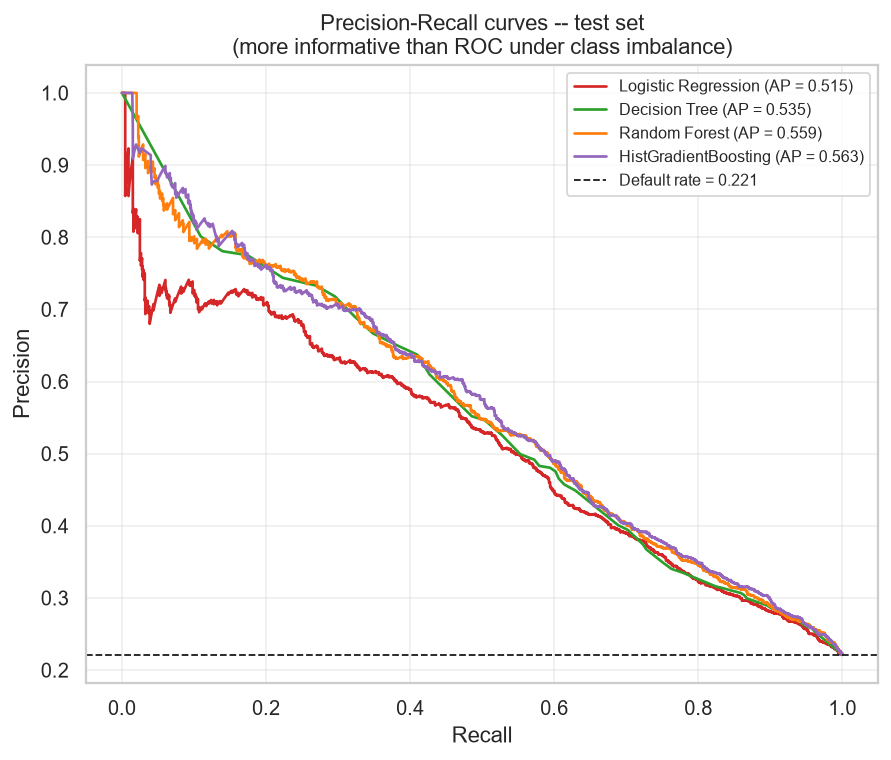

In [17]:
for fig in ["model_comparison.png", "confusion_matrices.png",
            "roc_curves.png", "precision_recall_curves.png"]:
    display(Image(filename=str(config.FIGURES_DIR / fig)))

## 9. Choosing the metric — the credit-risk argument

| Outcome | Meaning for the lender | Cost |
|---|---|---|
| **False Negative** — predicted repay, actually defaulted | A bad loan was **approved**. The bank loses the outstanding principal. | **High** |
| **False Positive** — predicted default, actually repaid | A good customer was **declined**. The bank loses the profit margin and some goodwill. | Lower |

* **Precision** = of the applicants we flagged as risky, how many really defaulted?
  Higher precision → fewer good customers wrongly rejected.
* **Recall** = of all the customers who actually defaulted, how many did we catch?
  Higher recall → fewer bad loans slipping through.
* **F1** = harmonic mean, used when both matter.
* **ROC-AUC** = probability the model ranks a random defaulter above a random payer.
  Threshold-independent, which makes it the right criterion for *choosing a model*.

**Conclusion.** We select the model on **ROC-AUC** (ranking quality), then tune the
**decision threshold** to favour **recall**, because a false negative is the expensive
error. We assume FN costs 5× FP and minimise total cost on out-of-fold predictions.

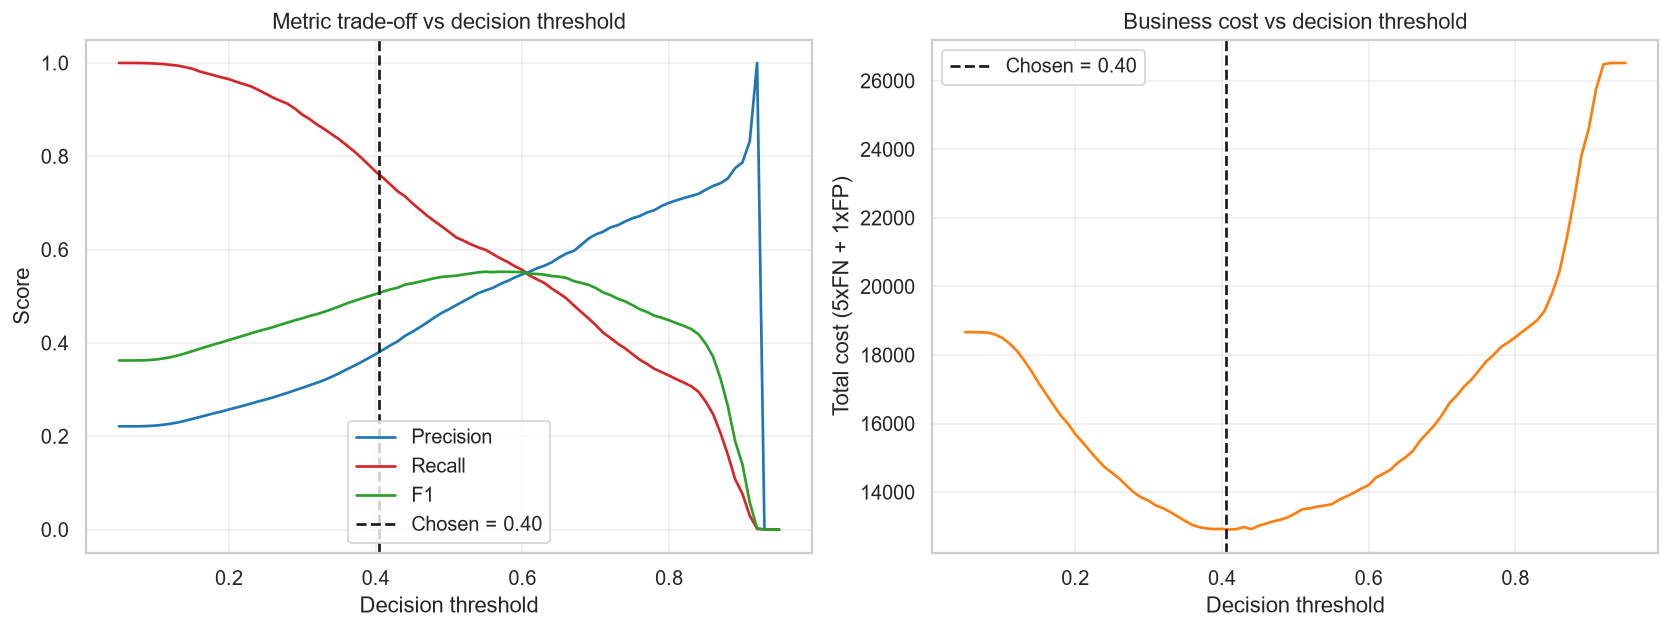

Selected model     : HistGradientBoosting
Best parameters    : {'model__min_samples_leaf': 50, 'model__max_leaf_nodes': 15, 'model__max_iter': 150, 'model__learning_rate': 0.03, 'model__l2_regularization': 0.5}
CV ROC-AUC         : 0.7899
Decision threshold : 0.405  (cost model: FN=5x, FP=1x)

Test metrics at the tuned threshold:
  Accuracy   0.6738
  Precision  0.3796
  Recall     0.7481
  F1         0.5037
  ROC-AUC    0.7818
  PR-AUC     0.5631


In [18]:
display(Image(filename=str(config.FIGURES_DIR / "threshold_analysis.png")))

summary = json.loads((config.RESULTS_DIR / "final_model_summary.json").read_text())
print(f"Selected model     : {summary['model_name']}")
print(f"Best parameters    : {summary['best_params']}")
print(f"CV ROC-AUC         : {summary['cv_roc_auc']:.4f}")
print(f"Decision threshold : {summary['threshold']:.3f}  "
      f"(cost model: FN={summary['cost_fn']:.0f}x, FP={summary['cost_fp']:.0f}x)")
print()
print("Test metrics at the tuned threshold:")
for k, v in summary["test_metrics_at_threshold"].items():
    print(f"  {k:<10} {v:.4f}")

## 10. Interpretability — what drives credit risk?

Permutation importance measures the real drop in test ROC-AUC when a column is shuffled.
It is model-agnostic and, unlike impurity importance, is not biased toward
high-cardinality features.

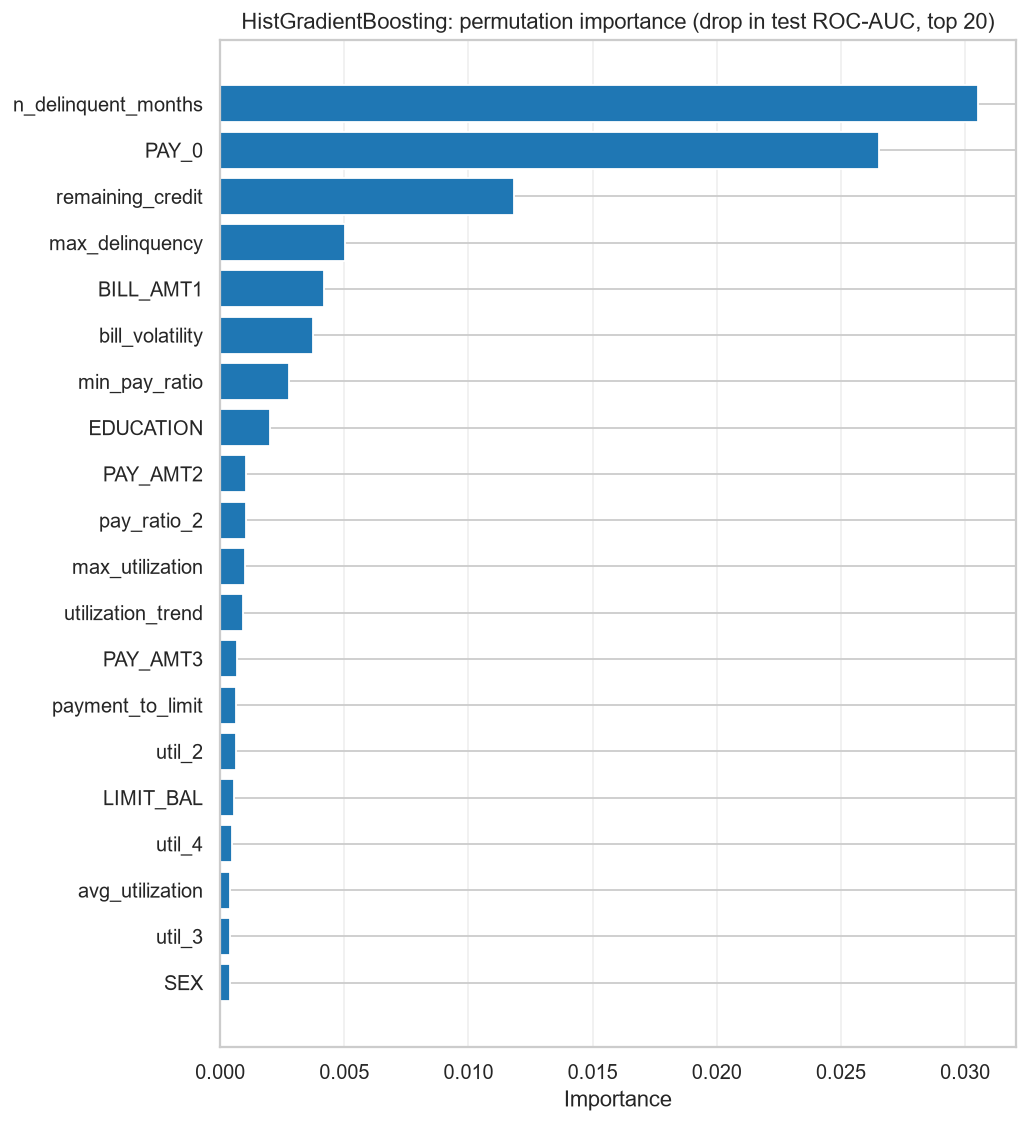

Selected model has no built-in importance attribute - permutation importance above is the reference measure.


,feature,importance,std
0,n_delinquent_months,0.03050,0.00224
1,PAY_0,0.02654,0.00343
2,remaining_credit,0.01183,0.00188
3,max_delinquency,0.00503,0.00097
4,BILL_AMT1,0.00417,0.00063
5,bill_volatility,0.00374,0.00069
6,min_pay_ratio,0.00277,0.00064
7,EDUCATION,0.00199,0.00059
8,PAY_AMT2,0.00105,0.00079
9,pay_ratio_2,0.00104,0.00028


In [19]:
display(Image(filename=str(config.FIGURES_DIR / "feature_importance_permutation.png")))

# Only tree/linear models expose a built-in importance attribute.
native = config.FIGURES_DIR / "feature_importance_native.png"
if native.exists():
    display(Image(filename=str(native)))
else:
    print("Selected model has no built-in importance attribute "
          "- permutation importance above is the reference measure.")

imp = pd.read_csv(config.RESULTS_DIR / "feature_importance.csv")
perm = imp[imp["type"] == "permutation_roc_auc_drop"].nlargest(12, "importance")
perm[["feature", "importance", "std"]].round(5).reset_index(drop=True)

## 11. Error analysis

Where does the model go wrong, and is it wrong *confidently* or *narrowly*?

In [20]:
err = pd.read_csv(config.RESULTS_DIR / "error_analysis.csv")
err.round(3)

,group,count,share,mean_predicted_prob,LIMIT_BAL,AGE,PAY_0,n_delinquent_months,avg_utilization,avg_pay_ratio,max_delinquency
0,True Negative (correctly approved),3046,0.508,0.254,205869.993,35.457,-0.429,0.060,0.324,0.442,-0.214
1,False Positive (good customer rejected),1621,0.270,0.584,126255.398,35.333,0.143,1.349,0.383,0.383,0.977
2,False Negative (defaulter approved),334,0.056,0.294,179790.419,35.632,-0.422,0.081,0.380,0.438,-0.177
3,True Positive (defaulter caught),992,0.166,0.721,116683.468,36.409,1.016,2.656,0.478,0.207,1.754


## 12. Prediction system — scoring a brand-new applicant

The saved bundle contains the **entire** pipeline (imputation → scaling → encoding →
classifier) plus the tuned threshold, so raw applicant data can be scored directly.
Every number below comes from the trained model at run time.

In [21]:
from src.predict import (
    load_model, predict_applicant, predict_batch, example_applicants, format_report,
)

bundle = load_model()
print(f"Model      : {bundle['model_name']}")
print(f"Trained at : {bundle['trained_at']}")
print(f"Threshold  : {bundle['threshold']:.3f}\n")

for title, applicant in example_applicants().items():
    print(format_report(predict_applicant(applicant, bundle), title))
    print()

Model      : HistGradientBoosting
Trained at : 2026-09-05T01:03:35
Threshold  : 0.405

----------------------------------------------------------
  Applicant A -- strong payer
----------------------------------------------------------
  Model used                 : HistGradientBoosting
  Prediction                 : GOOD CREDIT (likely to repay)
  Decision                   : APPROVE
  Risk category              : LOW RISK
  Probability of GOOD credit : 88.7%
  Probability of BAD credit  : 11.3%
  Decision threshold         : 0.405
----------------------------------------------------------

----------------------------------------------------------
  Applicant B -- distressed borrower
----------------------------------------------------------
  Model used                 : HistGradientBoosting
  Prediction                 : BAD CREDIT (likely to default)
  Decision                   : DECLINE / REVIEW
  Risk category              : VERY HIGH RISK
  Probability of GOOD credit : 14.9%
  

In [22]:
# Batch scoring: score the first 10 real test customers and compare to truth
raw_cols = bundle["raw_input_columns"]
sample = df.loc[X_test.index[:10], raw_cols]
scored = predict_batch(sample, bundle)
scored["actual_outcome"] = np.where(
    y_test.loc[sample.index] == 1, "defaulted", "repaid")
scored

,probability_of_default,probability_of_good_credit,risk_category,decision,actual_outcome
8681,0.3427,0.6573,MODERATE RISK,APPROVE,repaid
24179,0.2331,0.7669,MODERATE RISK,APPROVE,repaid
27755,0.3219,0.6781,MODERATE RISK,APPROVE,repaid
14938,0.5181,0.4819,HIGH RISK,DECLINE / REVIEW,repaid
1486,0.0944,0.9056,LOW RISK,APPROVE,repaid
1139,0.1210,0.8790,LOW RISK,APPROVE,repaid
26456,0.4000,0.6000,MODERATE RISK,APPROVE,repaid
27719,0.3062,0.6938,MODERATE RISK,APPROVE,repaid
1071,0.2415,0.7585,MODERATE RISK,APPROVE,defaulted
6988,0.2493,0.7507,MODERATE RISK,APPROVE,repaid


## 13. Conclusions, limitations and next steps

**What predicts credit risk here?** Recent and repeated **payment delinquency**
(`PAY_0`, `n_delinquent_months`, `max_delinquency`) dominates, followed by
**repayment effort** (how much of the bill is actually paid) and **credit utilisation**.
Demographics contribute very little.

**Limitations**

1. **One market, one period** — Taiwanese credit-card holders in 2005. Behaviour and
   macroeconomic conditions differ elsewhere and today; the model needs revalidation
   before any other use.
2. **Six-month window** — no information on income, employment, other lenders, or
   longer credit history, all of which real bureaus use.
3. **Card default only** — predicts a missed *credit-card* payment, not bankruptcy or
   mortgage default.
4. **Assumed cost ratio** — the 5:1 FN:FP ratio is a modelling assumption; a real lender
   would use its own loss-given-default figures.
5. **Fairness** — `SEX`, `EDUCATION` and `MARRIAGE` are protected or proxy attributes and
   using them in lending is restricted in many jurisdictions. `outputs/results/fairness_sensitivity.csv`
   records how much predictive power is lost when `SEX` is dropped.
6. **Selection bias** — the data contains only *approved* applicants, so it cannot
   describe people who were already declined.

**Next steps:** calibration curves, monotonic constraints for regulatory
explainability, scorecard (WOE/IV) conversion, and monitoring for population drift.